In [1]:
%cd ..

/Users/admin/repos/conferease


In [2]:
%load_ext autoreload
%autoreload 2

29.97002997002997 87 1280 720


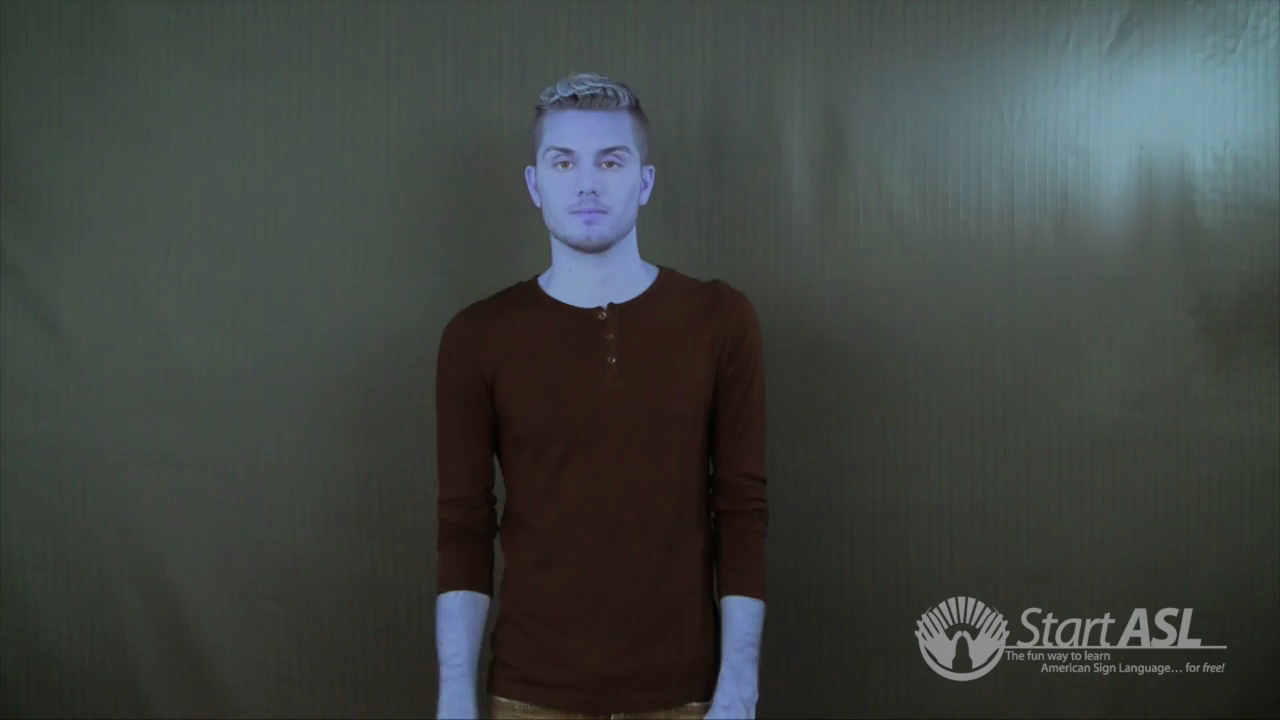

In [3]:
import cv2
from PIL import Image
import numpy as np

video_path = 'WLASL/start_kit/raw_videos/05727.mp4'

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(fps, frame_count, frame_width, frame_height)

_, frame = cap.read()

# convert to PIL image to view
numpy_frame_from_opencv = np.array(frame)
pil_frame = Image.fromarray(numpy_frame_from_opencv)
pil_frame

In [4]:
import cv2
import mediapipe as mp
import numpy as np
import json

def convert_to_3d(landmarks, image_width, image_height, scale_factor=100):
    landmarks_3d = []
    for landmark in landmarks:
        x = landmark.x * image_width * scale_factor
        y = (1 - landmark.y) * image_height * scale_factor  # Invert Y
        z = landmark.z * scale_factor
        landmarks_3d.append([x, y, z])
    return landmarks_3d


def process_frame(frame, mp_pose, mp_hands, image_width, image_height):
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pose_results = mp_pose.process(image)
    hand_results = mp_hands.process(image)
    
    frame_data = {}
    if pose_results.pose_landmarks:
        frame_data['pose'] = convert_to_3d(pose_results.pose_landmarks.landmark, image_width, image_height)
    if hand_results.multi_hand_landmarks:
        hand_landmarks = []
        for hand_landmark in hand_results.multi_hand_landmarks:
            hand_landmarks.append(convert_to_3d(hand_landmark.landmark, image_width, image_height))
        frame_data['hands'] = hand_landmarks
    
    return frame_data

def process_video(video_path, num_frames=10):
    # Open the video file
    cap = cv2.VideoCapture(video_path)

    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"FPS: {fps}, Total Frames: {frame_count}, Width: {frame_width}, Height: {frame_height}")

    # Calculate frame indices for 10 evenly spaced frames
    frame_indices = np.linspace(0, frame_count - 1, num_frames, dtype=int)

    animation_data = {
        "frame_rate": fps,
        "keyframes": []
    }
    
    mp_pose = mp.solutions.pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
    mp_hands = mp.solutions.hands.Hands(min_detection_confidence=0.5, min_tracking_confidence=0.5)
    
    all_coords = {'x': [], 'y': [], 'z': []}
    
    for frame_index in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
        ret, frame = cap.read()
        if not ret:
            print(f"Failed to read frame {frame_index}")
            continue
        frame_data = process_frame(frame, mp_pose, mp_hands, frame_width, frame_height)
        
        # Collect coordinates for bounds calculation
        if 'pose' in frame_data:
            for coord in frame_data['pose']:
                all_coords['x'].append(coord[0])
                all_coords['y'].append(coord[1])
                all_coords['z'].append(coord[2])
        if 'hands' in frame_data:
            for hand in frame_data['hands']:
                for coord in hand:
                    all_coords['x'].append(coord[0])
                    all_coords['y'].append(coord[1])
                    all_coords['z'].append(coord[2])
                    
        # Add to animation data
        animation_data["keyframes"].append({
            "frame": int(frame_index),
            "landmarks": frame_data
        })

    cap.release()
    
    # Calculate bounds
    x_min, x_max = min(all_coords['x']), max(all_coords['x'])
    y_min, y_max = min(all_coords['y']), max(all_coords['y'])
    z_min, z_max = min(all_coords['z']), max(all_coords['z'])
    
    animation_data['bounds'] = {
        'x': [x_min, x_max],
        'y': [y_min, y_max],
        'z': [z_min, z_max]
    }
    
    return animation_data

In [5]:
animation_data = process_video(video_path, 20)

FPS: 29.97002997002997, Total Frames: 87, Width: 1280, Height: 720


I0000 00:00:1719423457.152878 16041604 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
I0000 00:00:1719423457.161451 16041604 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88.1), renderer: Apple M1
W0000 00:00:1719423457.171143 16041830 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1719423457.179520 16041830 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1719423457.279997 16041821 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1719423457.288542 16041819 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feed

In [21]:
import plotly.graph_objects as go
import json
from mp_landmark_labels import pose_landmarks, hand_landmarks

# Get bounds from the animation data
x_bounds = animation_data['bounds']['x']
y_bounds = animation_data['bounds']['y']
z_bounds = animation_data['bounds']['z']


# Function to calculate the average point for the head
def calculate_head_point(pose_landmarks_data):
    head_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    x, y, z = 0, 0, 0
    for idx in head_indices:
        x += pose_landmarks_data[idx][0]
        y += pose_landmarks_data[idx][1]
        z += pose_landmarks_data[idx][2]
    count = len(head_indices)
    return [x / count, y / count, z / count]

# Function to plot landmarks for a specific frame
def plot_frame_landmarks(frame_index):
    frame_data = animation_data["keyframes"][frame_index]["landmarks"]
    
    fig = go.Figure()
    
    # Plot head point
    if 'pose' in frame_data:
        pose_landmarks_data = frame_data['pose']
        head_point = calculate_head_point(pose_landmarks_data)
        fig.add_trace(go.Scatter3d(
            x=[head_point[0]], y=[head_point[1]], z=[head_point[2]],
            mode='markers+text',
            marker=dict(size=5, color='red'),
            text=['Head'],
            textposition="bottom center"
        ))
        
        # Plot left wrist
        left_wrist = pose_landmarks_data[15]
        fig.add_trace(go.Scatter3d(
            x=[left_wrist[0]], y=[left_wrist[1]], z=[left_wrist[2]],
            mode='markers+text',
            marker=dict(size=5, color='green'),
            text=['Left Wrist'],
            textposition="bottom center"
        ))
        
        # Plot right wrist
        right_wrist = pose_landmarks_data[16]
        fig.add_trace(go.Scatter3d(
            x=[right_wrist[0]], y=[right_wrist[1]], z=[right_wrist[2]],
            mode='markers+text',
            marker=dict(size=5, color='green'),
            text=['Right Wrist'],
            textposition="bottom center"
        ))

        # plot shoulders 
        left_shoulder = pose_landmarks_data[11]
        right_shoulder = pose_landmarks_data[12]
        fig.add_trace(go.Scatter3d(
            x=[left_shoulder[0], right_shoulder[0]],
            y=[left_shoulder[1], right_shoulder[1]],
            z=[left_shoulder[2], right_shoulder[2]],
            mode='markers+text',
            marker=dict(size=5, color='orange'),
            text=['Left Shoulder', 'Right Shoulder'],
            textposition="bottom center"
        ))

        # plot elbows
        left_elbow = pose_landmarks_data[13]
        right_elbow = pose_landmarks_data[14]
        fig.add_trace(go.Scatter3d(
            x=[left_elbow[0], right_elbow[0]],
            y=[left_elbow[1], right_elbow[1]],
            z=[left_elbow[2], right_elbow[2]],
            mode='markers+text',
            marker=dict(size=5, color='orange'),
            text=['Left Elbow', 'Right Elbow'],
            textposition="bottom center"
        ))
        
    
    # Plot hand landmarks
    if 'hands' in frame_data:
        hand_landmarks_data = frame_data['hands']
        for hand_ind, hand in enumerate(hand_landmarks_data):
            # get centerpoint based on pose landmarks
            wrist_point = left_wrist if hand_ind == 0 else right_wrist
            for i, landmark in enumerate(hand):
                # center points on wrist
                x = landmark[0]
                y = landmark[1] 
                z = landmark[2] - wrist_point[2]
                
                fig.add_trace(go.Scatter3d(
                    x=[x], y=[y], z=[z],
                    mode='markers+text',
                    marker=dict(size=5, color='blue'),
                    text=[hand_landmarks[i]],
                    textposition="bottom center"
                ))
    
    fig.update_layout(scene=dict(
        xaxis=dict(range=[x_bounds[0], x_bounds[1]], autorange=False),
        yaxis=dict(range=[y_bounds[0], y_bounds[1]], autorange=False),
        zaxis=dict(range=[z_bounds[0], z_bounds[1]], autorange=False),
        aspectmode='cube'
    ))
    
    fig.show()

# Example usage: Plot the first frame
plot_frame_landmarks(10)
